In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("✅ All imports successful!")

✅ All imports successful!


In [2]:
PROCESSED_PATH = r"D:\Development\8th Sem Project\TomatoClassification\dataset\processed_mixed"
MODEL_PATH     = r"D:\Development\8th Sem Project\TomatoClassification\models"
IMAGE_SIZE     = (224, 224)
BATCH_SIZE     = 32
STRATEGY       = "C_Mixed"

model = load_model(os.path.join(MODEL_PATH, 'best_model_C_Mixed.h5'))

print(f"✅ Strategy {STRATEGY} model loaded!")
print(f"📊 Input shape  : {model.input_shape}")
print(f"📊 Output shape : {model.output_shape}")

✅ Strategy C_Mixed model loaded!
📊 Input shape  : (None, 224, 224, 3)
📊 Output shape : (None, 10)


In [3]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    os.path.join(PROCESSED_PATH, 'test'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(test_generator.class_indices.keys())
class_names_short = [c.replace("Tomato___", "").replace("_", " ")
                     for c in class_names]

print(f"✅ Test data loaded!")
print(f"🧪 Total test images : {test_generator.samples}")
print(f"📋 Classes           : {len(class_names)}")
for i, name in enumerate(class_names_short):
    print(f"  {i:2d} → {name}")

Found 1462 images belonging to 10 classes.
✅ Test data loaded!
🧪 Total test images : 1462
📋 Classes           : 10
   0 → Bacterial spot
   1 → Early blight
   2 → Late blight
   3 → Leaf Mold
   4 → Septoria leaf spot
   5 → Spider mites Two-spotted spider mite
   6 → Target Spot
   7 → Tomato Yellow Leaf Curl Virus
   8 → Tomato mosaic virus
   9 → healthy


In [4]:
print(f"🔄 Evaluating Strategy {STRATEGY} on test set...\n")

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\n{'='*50}")
print(f"📊 Strategy {STRATEGY} — Test Results")
print(f"{'='*50}")
print(f"✅ Test Accuracy : {test_accuracy:.2%}")
print(f"📉 Test Loss     : {test_loss:.4f}")
print(f"{'='*50}")

print(f"\n📈 All Strategies Comparison:")
print(f"  Strategy A (Color only)    : 89.06% 🥇")
print(f"  Strategy C (Mixed 50/50)   : {test_accuracy:.2%} 🥈")
print(f"  Strategy B (Segmented only): 86.13% 🥉")
print(f"\n  C vs A : {(test_accuracy - 0.8906)*100:+.2f}%")
print(f"  C vs B : {(test_accuracy - 0.8613)*100:+.2f}%")

🔄 Evaluating Strategy C_Mixed on test set...

46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 856ms/step - accuracy: 0.8748 - loss: 0.3631

📊 Strategy C_Mixed — Test Results
✅ Test Accuracy : 87.48%
📉 Test Loss     : 0.3631

📈 All Strategies Comparison:
  Strategy A (Color only)    : 89.06% 🥇
  Strategy C (Mixed 50/50)   : 87.48% 🥈
  Strategy B (Segmented only): 86.13% 🥉

  C vs A : -1.58%
  C vs B : +1.35%


🔄 Generating predictions...
46/46 ━━━━━━━━━━━━━━━━━━━━ 33s 702ms/step


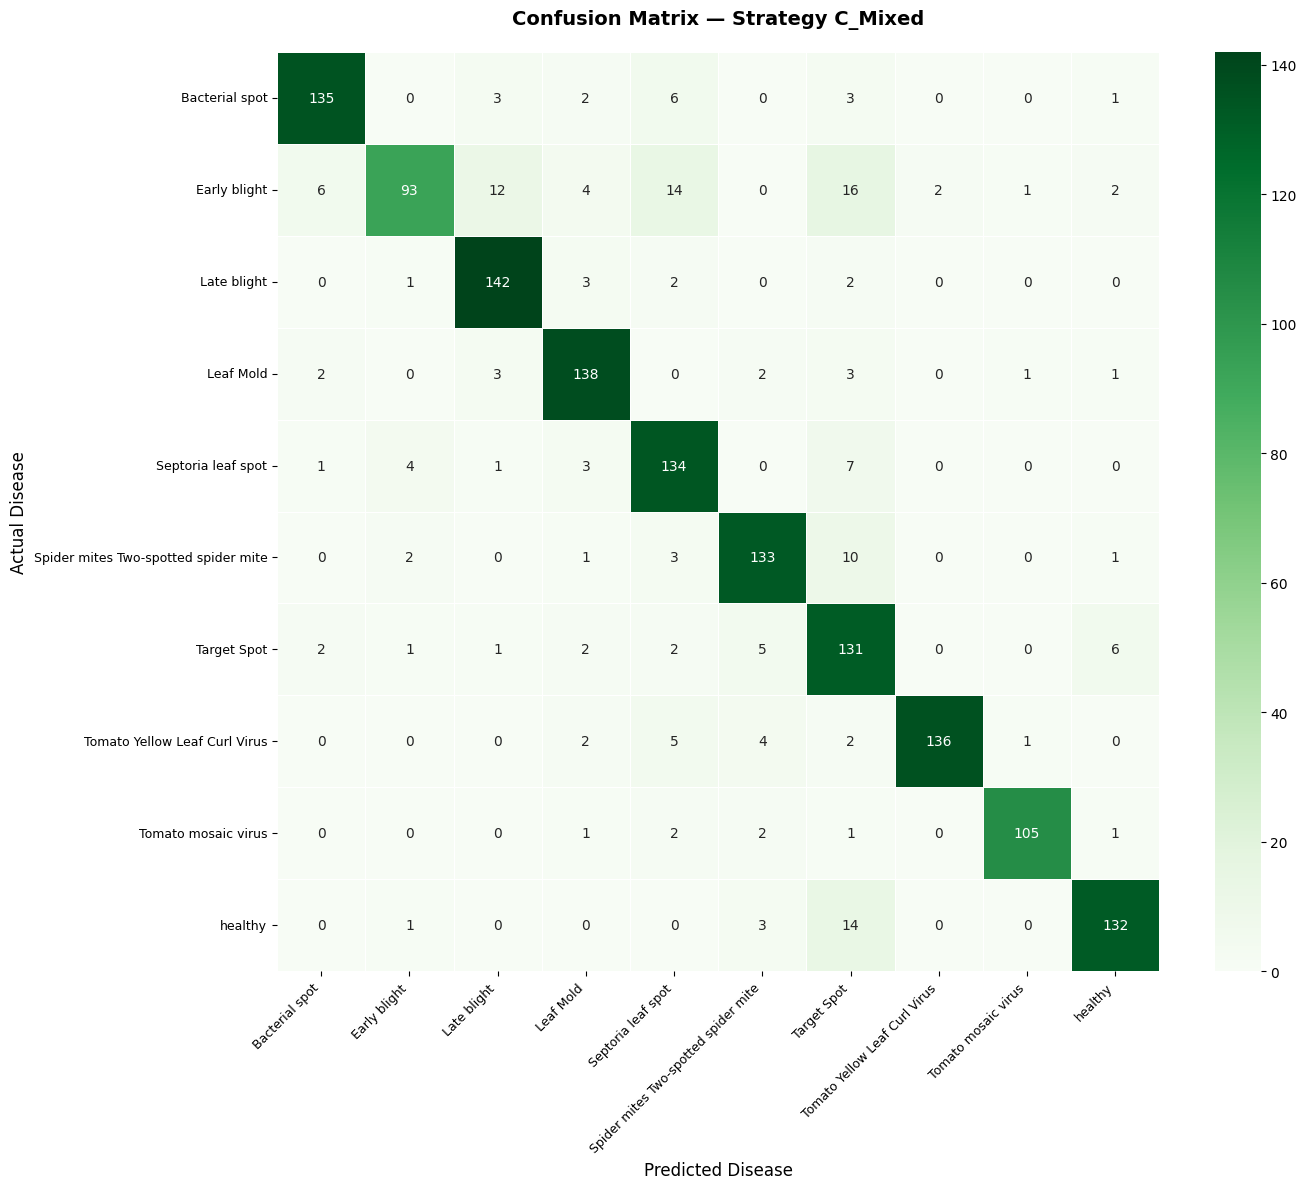

✅ Confusion matrix saved!


In [5]:
print("🔄 Generating predictions...")

predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',         # Green for Strategy C
    xticklabels=class_names_short,
    yticklabels=class_names_short,
    linewidths=0.5
)
plt.title(f'Confusion Matrix — Strategy {STRATEGY}',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Actual Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

os.makedirs("../outputs", exist_ok=True)
plt.savefig(f"../outputs/confusion_matrix_{STRATEGY}.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

📋 Classification Report — Strategy C_Mixed

                                      precision    recall  f1-score   support

                      Bacterial spot      0.925     0.900     0.912       150
                        Early blight      0.912     0.620     0.738       150
                         Late blight      0.877     0.947     0.910       150
                           Leaf Mold      0.885     0.920     0.902       150
                  Septoria leaf spot      0.798     0.893     0.843       150
Spider mites Two-spotted spider mite      0.893     0.887     0.890       150
                         Target Spot      0.693     0.873     0.773       150
       Tomato Yellow Leaf Curl Virus      0.986     0.907     0.944       150
                 Tomato mosaic virus      0.972     0.938     0.955       112
                             healthy      0.917     0.880     0.898       150

                            accuracy                          0.875      1462
                  

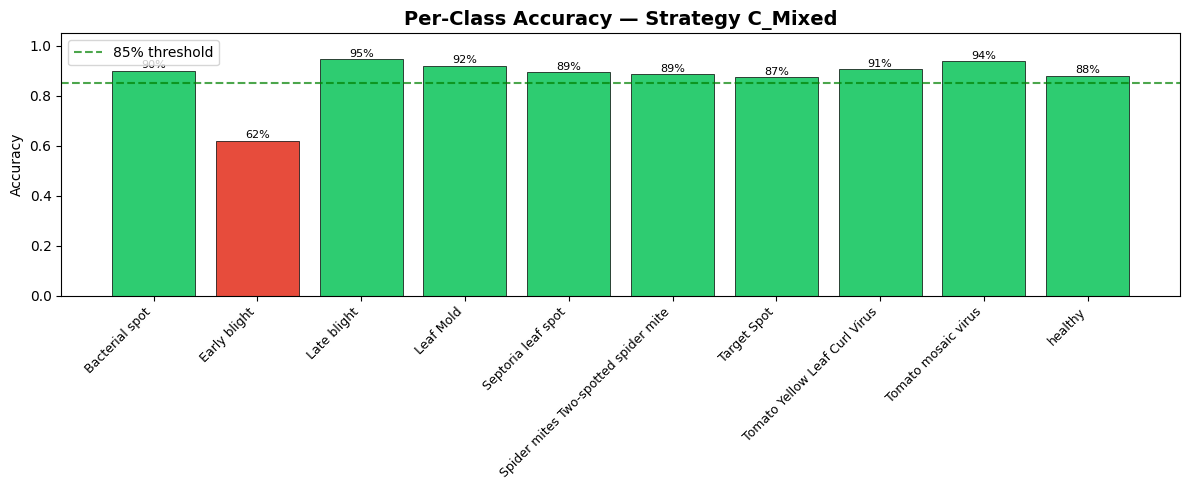

✅ Per-class chart saved!


In [6]:
report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names_short,
    digits=3
)

print(f"📋 Classification Report — Strategy {STRATEGY}\n")
print(report)

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(12, 5))
colors = ['#2ecc71' if acc >= 0.85 else '#f39c12' if acc >= 0.70
          else '#e74c3c' for acc in per_class_accuracy]

bars = plt.bar(class_names_short, per_class_accuracy,
               color=colors, edgecolor='black', linewidth=0.5)

plt.axhline(y=0.85, color='green', linestyle='--',
            alpha=0.7, label='85% threshold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel("Accuracy")
plt.title(f"Per-Class Accuracy — Strategy {STRATEGY}",
          fontsize=14, fontweight='bold')
plt.ylim(0, 1.05)
plt.legend()

for bar, acc in zip(bars, per_class_accuracy):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{acc:.0%}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(f"../outputs/per_class_accuracy_{STRATEGY}.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Per-class chart saved!")

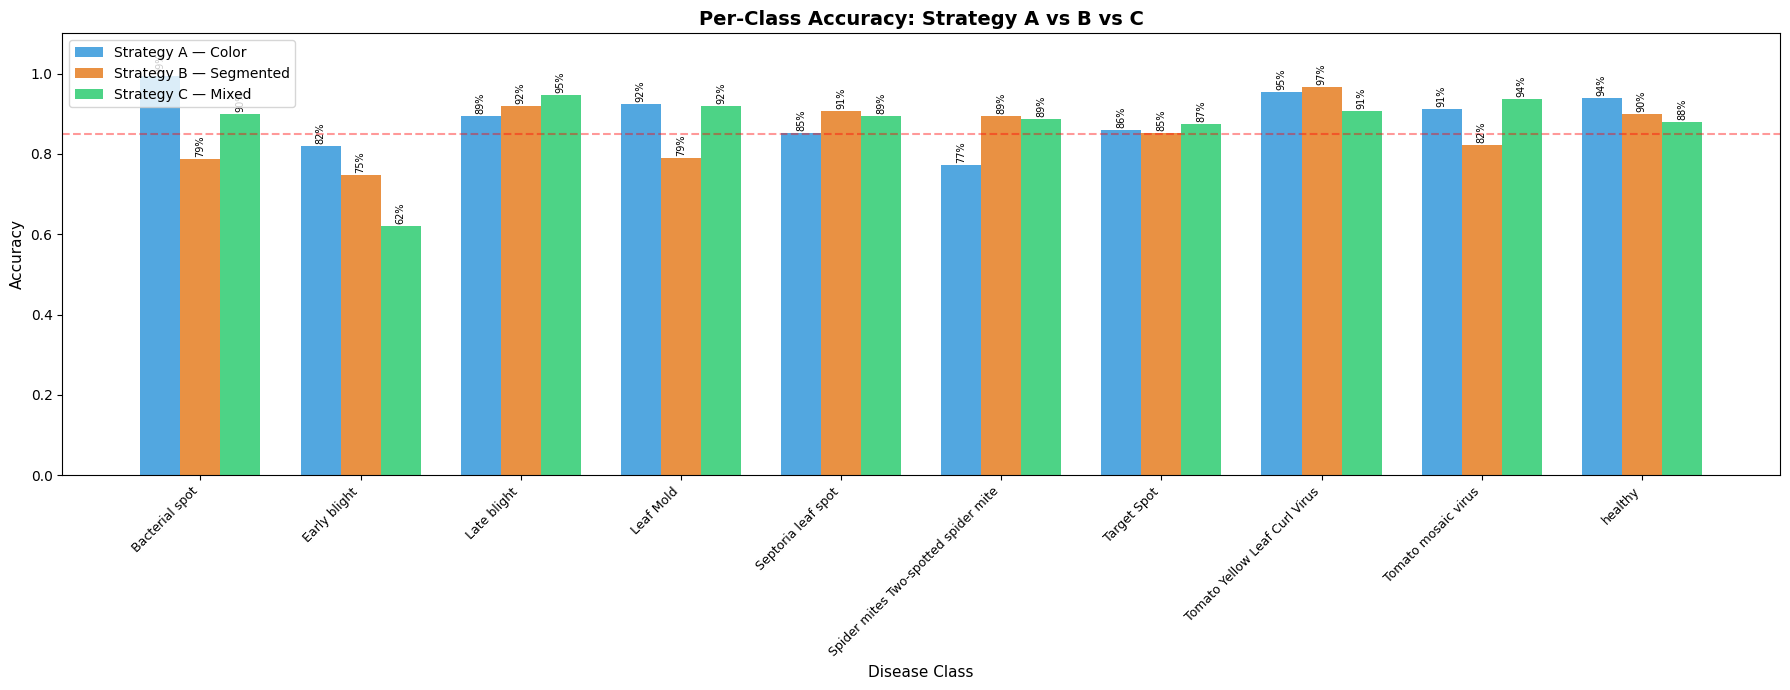


Class                                               A       B       C     C-A     C-B       Best
───────────────────────────────────────────────────────────────────────────────────────────────
Bacterial spot                                  99.3%   78.7%   90.0%   -9.3%  +11.3%         A🔵
Early blight                                    82.0%   74.7%   62.0%  -20.0%  -12.7%         A🔵
Late blight                                     89.3%   92.0%   94.7%   +5.4%   +2.7%         C🟢
Leaf Mold                                       92.3%   79.0%   92.0%   -0.3%  +13.0%         A🔵
Septoria leaf spot                              85.3%   90.7%   89.3%   +4.0%   -1.4%         B🟠
Spider mites Two-spotted spider mite            77.3%   89.3%   88.7%  +11.4%   -0.6%         B🟠
Target Spot                                     86.0%   85.3%   87.3%   +1.3%   +2.0%         C🟢
Tomato Yellow Leaf Curl Virus                   95.3%   96.7%   90.7%   -4.6%   -6.0%         B🟠
Tomato mosaic virus           

In [7]:
# ── Known results from previous evaluations ──
strategy_A = {
    'Bacterial spot'                        : 0.993,
    'Early blight'                          : 0.820,
    'Late blight'                           : 0.893,
    'Leaf Mold'                             : 0.923,
    'Septoria leaf spot'                    : 0.853,
    'Spider mites Two-spotted spider mite'  : 0.773,
    'Target Spot'                           : 0.860,
    'Tomato Yellow Leaf Curl Virus'         : 0.953,
    'Tomato mosaic virus'                   : 0.911,
    'healthy'                               : 0.940
}

strategy_B = {
    'Bacterial spot'                        : 0.787,
    'Early blight'                          : 0.747,
    'Late blight'                           : 0.920,
    'Leaf Mold'                             : 0.790,
    'Septoria leaf spot'                    : 0.907,
    'Spider mites Two-spotted spider mite'  : 0.893,
    'Target Spot'                           : 0.853,
    'Tomato Yellow Leaf Curl Virus'         : 0.967,
    'Tomato mosaic virus'                   : 0.821,
    'healthy'                               : 0.900
}

strategy_C = dict(zip(class_names_short, per_class_accuracy))

# ── 3-bar grouped chart ──
x = np.arange(len(class_names_short))
width = 0.25

fig, ax = plt.subplots(figsize=(18, 7))

bars_A = ax.bar(x - width, list(strategy_A.values()),
                width, label='Strategy A — Color',
                color='#3498db', alpha=0.85)
bars_B = ax.bar(x,          list(strategy_B.values()),
                width, label='Strategy B — Segmented',
                color='#e67e22', alpha=0.85)
bars_C = ax.bar(x + width,  list(strategy_C.values()),
                width, label='Strategy C — Mixed',
                color='#2ecc71', alpha=0.85)

ax.set_xlabel('Disease Class', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Per-Class Accuracy: Strategy A vs B vs C',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names_short, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.axhline(y=0.85, color='red', linestyle='--', alpha=0.4, label='85% threshold')
ax.set_ylim(0, 1.1)

# Add value labels on top of each bar
for bars in [bars_A, bars_B, bars_C]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.0%}',
                ha='center', fontsize=7, rotation=90)

plt.tight_layout()
plt.savefig("../outputs/comparison_A_vs_B_vs_C.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Detailed difference table ──
print(f"\n{'Class':<45} {'A':>7} {'B':>7} {'C':>7} {'C-A':>7} {'C-B':>7} {'Best':>10}")
print("─" * 95)

for cls in class_names_short:
    a = strategy_A.get(cls, 0)
    b = strategy_B.get(cls, 0)
    c = strategy_C.get(cls, 0)
    diff_ca = (c - a) * 100
    diff_cb = (c - b) * 100
    best = 'A🔵' if a >= b and a >= c else 'B🟠' if b >= a and b >= c else 'C🟢'
    print(f"{cls:<45} {a:>7.1%} {b:>7.1%} {c:>7.1%} "
          f"{diff_ca:>+6.1f}% {diff_cb:>+6.1f}% {best:>10}")

print("─" * 95)
print(f"\n{'OVERALL':<45} {'89.1%':>7} {'86.1%':>7} {test_accuracy:>7.1%}")

# ── Winner count summary ──
a_wins = sum(1 for cls in class_names_short
             if strategy_A[cls] >= strategy_B.get(cls,0)
             and strategy_A[cls] >= strategy_C.get(cls,0))
b_wins = sum(1 for cls in class_names_short
             if strategy_B.get(cls,0) >= strategy_A[cls]
             and strategy_B.get(cls,0) >= strategy_C.get(cls,0))
c_wins = sum(1 for cls in class_names_short
             if strategy_C.get(cls,0) >= strategy_A[cls]
             and strategy_C.get(cls,0) >= strategy_B.get(cls,0))

print(f"\n🏆 Class-level wins:")
print(f"   Strategy A (Color)     won {a_wins}/10 classes 🔵")
print(f"   Strategy B (Segmented) won {b_wins}/10 classes 🟠")
print(f"   Strategy C (Mixed)     won {c_wins}/10 classes 🟢")

In [8]:
results_path = r"D:\Development\8th Sem Project\TomatoClassification\outputs\results_summary.txt"

with open(results_path, 'a') as f:
    f.write(f"\nStrategy {STRATEGY} — Evaluation\n")
    f.write(f"  Test Accuracy    : {test_accuracy:.4f}\n")
    f.write(f"  Test Loss        : {test_loss:.4f}\n")
    f.write(f"  Classification Report:\n{report}\n")

print(f"✅ Results saved!")
print(f"\n📁 Output files created:")
print(f"   confusion_matrix_{STRATEGY}.png")
print(f"   per_class_accuracy_{STRATEGY}.png")
print(f"   comparison_A_vs_B_vs_C.png          ← main research chart")

✅ Results saved!

📁 Output files created:
   confusion_matrix_C_Mixed.png
   per_class_accuracy_C_Mixed.png
   comparison_A_vs_B_vs_C.png          ← main research chart
